In [1]:
pip install catboost xgboost lightgbm optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 26.7 MB/s eta 0:00:00


In [3]:
pip install RDKit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 5.0 MB/s eta 0:00:00


In [16]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors, rdMolDescriptors, rdFingerprintGenerator
from rdkit import DataStructs

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

df = pd.read_csv("data.csv", encoding="utf-8-sig")
print(f"Dataset: {df.shape[0]} compounds, {df.shape[1]} columns")
df.head(10)

Dataset: 260 compounds, 26 columns


,Name,FuelClass,Smiles,P,S,T,Q+Qr,P*,S*,T*,...,Br,DD,SCpos,C=O,O,COO,nBP,RON,MON,OS
0,Ethane,Alkanes,CC,2,0,0,0,0,0,0,...,0.0,0,0,0,0,0,0,111.0,100.7,10.3
1,Propane,Alkanes,CCC,2,1,0,0,0,0,0,...,0.0,0,0,0,0,0,0,112.5,97.1,15.4
2,n-Butane,Alkanes,CCCC,2,2,0,0,0,0,0,...,0.0,0,0,0,0,0,0,93.6,90.1,3.5
3,n-Pentane,Alkanes,CCCCC,2,3,0,0,0,0,0,...,0.0,0,0,0,0,0,0,61.7,61.9,-0.2
4,n-Hexane,Alkanes,CCCCCC,2,4,0,0,0,0,0,...,0.0,0,0,0,0,0,0,24.8,26.0,-1.2
5,n-Heptane,Alkanes,CCCCCCCC,2,5,0,0,0,0,0,...,0.0,0,0,0,0,0,0,0.0,0.0,0.0
6,2-Methylpropane,Alkanes,CC(C)C,3,0,1,0,0,0,0,...,1.0,0,0,0,0,0,0,102.1,97.6,4.5
7,2-Methylbutane,Alkanes,CCC(C)C,3,1,1,0,0,0,0,...,1.0,0,0,0,0,0,0,92.3,90.3,2.0
8,2_2-Dimethylpropane,Alkanes,CC(C)(C)C,4,0,0,1,0,0,0,...,2.0,0,0,0,0,0,0,85.5,80.2,5.3
9,2-Methylpentane,Alkanes,CCCC(C)C,3,2,1,0,0,0,0,...,1.0,0,0,0,0,0,0,73.4,73.5,-0.1


In [13]:
# Проверим пропуски
missing = df.isnull().sum()
print("Пропущенные значения:")
print(missing[missing > 0])

# Удалим строки без целевой переменной RON
df_clean = df.dropna(subset=["RON", "MON"]).copy()
print(f"\nПосле удаления пропусков: {len(df_clean)} соединений")

Пропущенные значения:
RON     4
MON     7
OS     11
dtype: int64

После удаления пропусков: 249 соединений


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor

import optuna
from optuna.samplers import TPESampler

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [17]:
def compute_rdkit_2d_descriptors(smiles_list):
    desc_names = [
        "MolWt", "MolLogP", "TPSA", "NumHAcceptors", "NumHDonors",
        "NumRotatableBonds", "NumAromaticRings", "NumAliphaticRings",
        "RingCount", "FractionCSP3", "HeavyAtomCount"
    ]
    funcs = {name: getattr(Descriptors, name) for name in desc_names}
    records = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            records.append({name: np.nan for name in desc_names})
        else:
            records.append({name: funcs[name](mol) for name in desc_names})
    return pd.DataFrame(records)

def comp_fingerprints(smiles_list, radius=2, n_bits=1024):
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            fps.append(np.zeros(n_bits))
        else:
            fps.append(gen.GetFingerprintAsNumPy(mol))
    return pd.DataFrame(fps, columns=[f"morgan_{i}" for i in range(n_bits)])

def comp_maccs_keys(smiles_list):
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            arr = np.zeros(167, dtype=int)
        else:
            fp = rdMolDescriptors.GetMACCSKeysFingerprint(mol)
            arr = np.zeros(167, dtype=int)
            DataStructs.ConvertToNumpyArray(fp, arr)
        fps.append(arr)
    return pd.DataFrame(fps, columns=[f"maccs_{i}" for i in range(167)])

smiles = df_clean["Smiles"].tolist()
desc_2d = compute_rdkit_2d_descriptors(smiles)
morgan = comp_fingerprints(smiles, radius=2, n_bits=1024)
maccs = comp_maccs_keys(smiles)

X_raw = pd.concat([desc_2d, morgan, maccs], axis=1)
y_ron = df_clean["RON"].values
y_mon = df_clean["MON"].values

print(f"Исходная размерность признаков: {X_raw.shape}")

Исходная размерность признаков: (249, 1202)


In [18]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression

def remove_low_variance(X, threshold=0.01):
    sel = VarianceThreshold(threshold=threshold)
    sel.fit(X)
    return X.loc[:, sel.get_support()]

def remove_correlated(X, threshold=0.95):
    corr = X.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return X.drop(columns=to_drop)

def select_by_mutual_info(X, y, n_features=50):
    scores = mutual_info_regression(X, y, random_state=SEED)
    idx = np.argsort(scores)[::-1][:n_features]
    return X.iloc[:, idx]

X_filt = remove_low_variance(X_raw, threshold=0.01)
print(f"После низкой дисперсии: {X_filt.shape}")
X_filt = remove_correlated(X_filt, threshold=0.95)
print(f"После удаления корреляций: {X_filt.shape}")

X_ron_sel = select_by_mutual_info(X_filt, y_ron, n_features=50)
X_mon_sel = select_by_mutual_info(X_filt, y_mon, n_features=50)
print(f"Признаков RON: {X_ron_sel.shape[1]}, MON: {X_mon_sel.shape[1]}")

После низкой дисперсии: (249, 259)
После удаления корреляций: (249, 235)
Признаков RON: 50, MON: 50


In [19]:
X_train_ron, X_test_ron, y_train_ron, y_test_ron = train_test_split(
    X_ron_sel, y_ron, test_size=0.2, random_state=SEED)
X_train_mon, X_test_mon, y_train_mon, y_test_mon = train_test_split(
    X_mon_sel, y_mon, test_size=0.2, random_state=SEED)

print(f"Train RON: {X_train_ron.shape}, Test RON: {X_test_ron.shape}")
print(f"Train MON: {X_train_mon.shape}, Test MON: {X_test_mon.shape}")

Train RON: (199, 50), Test RON: (50, 50)
Train MON: (199, 50), Test MON: (50, 50)


In [20]:
def objective_rf(trial, X, y):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': SEED
    }
    model = RandomForestRegressor(**params, n_jobs=-1)
    return cross_val_score(model, X, y, cv=KFold(5, shuffle=True, random_state=SEED),
                           scoring='neg_mean_squared_error').mean()

def objective_xgb(trial, X, y):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2.0),
        'random_state': SEED, 'verbosity': 0
    }
    model = XGBRegressor(**params, n_jobs=-1)
    return cross_val_score(model, X, y, cv=KFold(5, shuffle=True, random_state=SEED),
                           scoring='neg_mean_squared_error').mean()

def objective_lgb(trial, X, y):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1.0),
        'random_state': SEED, 'verbose': -1
    }
    model = LGBMRegressor(**params, n_jobs=-1)
    return cross_val_score(model, X, y, cv=KFold(5, shuffle=True, random_state=SEED),
                           scoring='neg_mean_squared_error').mean()

def objective_cat(trial, X, y):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 800),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.5, 2.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 30)
    }
    model = CatBoostRegressor(**params, random_seed=SEED, verbose=0, thread_count=-1)
    return cross_val_score(model, X, y, cv=KFold(5, shuffle=True, random_state=SEED),
                           scoring='neg_mean_squared_error').mean()

def objective_gbm(trial, X, y):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': SEED
    }
    model = GradientBoostingRegressor(**params)
    return cross_val_score(model, X, y, cv=KFold(5, shuffle=True, random_state=SEED),
                           scoring='neg_mean_squared_error').mean()

def optimize_model(objective_func, X_train, y_train, n_trials=30, model_name='Model'):
    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
    study.optimize(lambda trial: objective_func(trial, X_train, y_train),
                   n_trials=n_trials, show_progress_bar=True)
    print(f"Лучшие параметры для {model_name}: {study.best_params}")
    return study.best_params

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return mae, rmse, r2

In [21]:
best_params_ron, models_ron = {}, {}
best_params_ron['RF'] = optimize_model(objective_rf, X_train_ron, y_train_ron, n_trials=20, model_name='RF_RON')
best_params_ron['XGB'] = optimize_model(objective_xgb, X_train_ron, y_train_ron, n_trials=20, model_name='XGB_RON')
best_params_ron['LGB'] = optimize_model(objective_lgb, X_train_ron, y_train_ron, n_trials=20, model_name='LGB_RON')
best_params_ron['CAT'] = optimize_model(objective_cat, X_train_ron, y_train_ron, n_trials=20, model_name='CAT_RON')
best_params_ron['GBM'] = optimize_model(objective_gbm, X_train_ron, y_train_ron, n_trials=20, model_name='GBM_RON')

models_ron['RF'] = RandomForestRegressor(**best_params_ron['RF'], random_state=SEED, n_jobs=-1)
models_ron['XGB'] = XGBRegressor(**best_params_ron['XGB'], random_state=SEED, n_jobs=-1, verbosity=0)
models_ron['LGB'] = LGBMRegressor(**best_params_ron['LGB'], random_state=SEED, n_jobs=-1, verbose=-1)
models_ron['CAT'] = CatBoostRegressor(**best_params_ron['CAT'], random_seed=SEED, verbose=0, thread_count=-1)
models_ron['GBM'] = GradientBoostingRegressor(**best_params_ron['GBM'], random_state=SEED)

for name, model in models_ron.items():
    model.fit(X_train_ron, y_train_ron)

[I 2026-04-23 21:09:12,701] A new study created in memory with name: no-name-f8efb5f4-e99b-4817-ad1d-621db50c9d0e


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-23 21:09:17,419] Trial 0 finished with value: -153.52865448593636 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: -153.52865448593636.
[I 2026-04-23 21:09:20,996] Trial 1 finished with value: -173.21209688448565 and parameters: {'n_estimators': 162, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: -153.52865448593636.
[I 2026-04-23 21:09:26,654] Trial 2 finished with value: -169.4365066270363 and parameters: {'n_estimators': 341, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: -153.52865448593636.
[I 2026-04-23 21:09:32,719] Trial 3 finished with value: -132.03012910959734 and parameters: {'n_estimators': 433, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 3 with value: -132.03012910959734.
[I 2026-04-23 21:09:34,449] Trial 4 finished with value: -141.46083150891644 and parame

[I 2026-04-23 21:10:27,926] A new study created in memory with name: no-name-1ebccc6a-cd5a-4644-bfaa-3ce60a856a78


[I 2026-04-23 21:10:27,921] Trial 19 finished with value: -138.370013682555 and parameters: {'n_estimators': 463, 'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 10 with value: -128.89335308978133.
Лучшие параметры для RF_RON: {'n_estimators': 478, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 1}


...

[I 2026-04-23 21:12:01,260] Trial 0 finished with value: -116.59937741397334 and parameters: {'iterations': 425, 'depth': 10, 'learning_rate': 0.1205712628744377, 'l2_leaf_reg': 0.6251373574521749, 'random_strength': 0.7340279606636548, 'bagging_temperature': 4.679835610086079}. Best is trial 0 with value: -116.59937741397334.
[I 2026-04-23 21:12:26,513] Trial 1 finished with value: -121.18143586477962 and parameters: {'iterations': 234, 'depth': 10, 'learning_rate': 0.07725378389307355, 'l2_leaf_reg': 1.3311216080736887, 'random_strength': 0.5308767414437037, 'bagging_temperature': 29.09729556485983}. Best is trial 0 with value: -116.59937741397334.
[I 2026-04-23 21:12:31,280] Trial 2 finished with value: -93.46736241498215 and parameters: {'iterations': 700, 'depth': 5, 'learning_rate': 0.01855998084649059, 'l2_leaf_reg': 0.03549878832196503, 'random_strength': 0.9563633644393066, 'bagging_temperature': 15.742692948967136}. Best is trial 2 with value: -93.46736241498215.
[I 2026-04-2

[I 2026-04-23 21:17:24,048] A new study created in memory with name: no-name-460c0d40-2703-4ce1-974a-54835fc45591


[I 2026-04-23 21:17:24,041] Trial 19 finished with value: -93.30358105550819 and parameters: {'iterations': 475, 'depth': 9, 'learning_rate': 0.05199768051334688, 'l2_leaf_reg': 3.2226893534412997, 'random_strength': 1.7608057875924676, 'bagging_temperature': 7.805008195389664}. Best is trial 17 with value: -89.22108396644822.
Лучшие параметры для CAT_RON: {'iterations': 491, 'depth': 6, 'learning_rate': 0.029780680575052343, 'l2_leaf_reg': 3.7339920591605105, 'random_strength': 1.3875350558795108, 'bagging_temperature': 6.580314817523984}


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-23 21:17:25,692] Trial 0 finished with value: -132.99731019438693 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 0 with value: -132.99731019438693.
[I 2026-04-23 21:17:26,340] Trial 1 finished with value: -123.9144984809097 and parameters: {'n_estimators': 123, 'max_depth': 9, 'learning_rate': 0.07725378389307355, 'subsample': 0.8832290311184181, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 1 with value: -123.9144984809097.
[I 2026-04-23 21:17:28,167] Trial 2 finished with value: -118.93614840433077 and parameters: {'n_estimators': 433, 'max_depth': 4, 'learning_rate': 0.01855998084649059, 'subsample': 0.6733618039413735, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 2 with value: -118.93614840433077.
[I 2026-04-23 21:17:29,679] Trial 3 finished with value: -122.57883219712096 and parameters: {'n_estimato

In [22]:
results_ron = {}
for name, model in models_ron.items():
    mae, rmse, r2 = evaluate_model(model, X_test_ron, y_test_ron)
    results_ron[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"RON {name} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.4f}")
df_res_ron = pd.DataFrame(results_ron).T

RON RF -> MAE: 7.606, RMSE: 10.100, R2: 0.7552
RON XGB -> MAE: 6.237, RMSE: 8.160, R2: 0.8402
RON LGB -> MAE: 7.269, RMSE: 9.463, R2: 0.7851
RON CAT -> MAE: 6.868, RMSE: 8.754, R2: 0.8161
RON GBM -> MAE: 7.003, RMSE: 9.055, R2: 0.8032


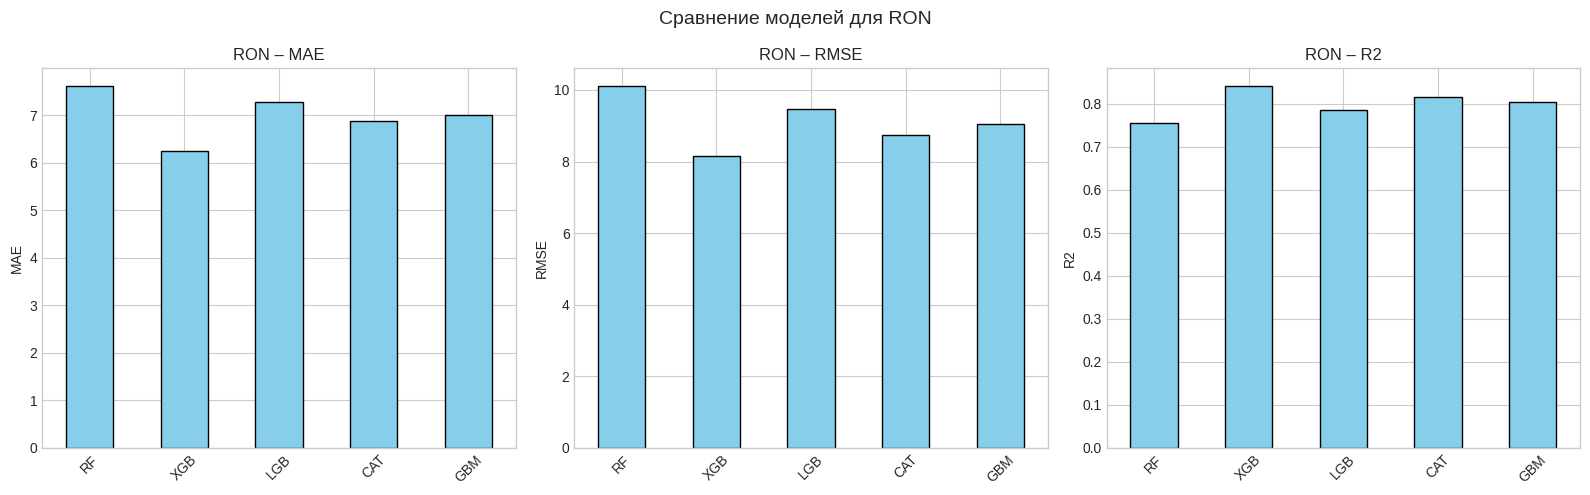

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    df_res_ron[metric].plot(kind='bar', ax=ax, color='skyblue', edgecolor='black')
    ax.set_title(f'RON – {metric}')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Сравнение моделей для RON', fontsize=14)
plt.tight_layout()
plt.show()

In [24]:
best_params_mon, models_mon = {}, {}
best_params_mon['RF'] = optimize_model(objective_rf, X_train_mon, y_train_mon, n_trials=20, model_name='RF_MON')
best_params_mon['XGB'] = optimize_model(objective_xgb, X_train_mon, y_train_mon, n_trials=20, model_name='XGB_MON')
best_params_mon['LGB'] = optimize_model(objective_lgb, X_train_mon, y_train_mon, n_trials=20, model_name='LGB_MON')
best_params_mon['CAT'] = optimize_model(objective_cat, X_train_mon, y_train_mon, n_trials=20, model_name='CAT_MON')
best_params_mon['GBM'] = optimize_model(objective_gbm, X_train_mon, y_train_mon, n_trials=20, model_name='GBM_MON')

models_mon['RF'] = RandomForestRegressor(**best_params_mon['RF'], random_state=SEED, n_jobs=-1)
models_mon['XGB'] = XGBRegressor(**best_params_mon['XGB'], random_state=SEED, n_jobs=-1, verbosity=0)
models_mon['LGB'] = LGBMRegressor(**best_params_mon['LGB'], random_state=SEED, n_jobs=-1, verbose=-1)
models_mon['CAT'] = CatBoostRegressor(**best_params_mon['CAT'], random_seed=SEED, verbose=0, thread_count=-1)
models_mon['GBM'] = GradientBoostingRegressor(**best_params_mon['GBM'], random_state=SEED)

for name, model in models_mon.items():
    model.fit(X_train_mon, y_train_mon)

[I 2026-04-23 21:18:03,193] A new study created in memory with name: no-name-d8f32c96-c822-4b97-888b-c4f48a2ba2c3


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-23 21:18:05,429] Trial 0 finished with value: -118.81209665759499 and parameters: {'n_estimators': 250, 'max_depth': 20, 'min_samples_split': 8, 'min_samples_leaf': 3}. Best is trial 0 with value: -118.81209665759499.
[I 2026-04-23 21:18:07,166] Trial 1 finished with value: -137.7135163196716 and parameters: {'n_estimators': 162, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: -118.81209665759499.
[I 2026-04-23 21:18:10,890] Trial 2 finished with value: -134.73463152889394 and parameters: {'n_estimators': 341, 'max_depth': 15, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: -118.81209665759499.
[I 2026-04-23 21:18:14,903] Trial 3 finished with value: -99.38501994171527 and parameters: {'n_estimators': 433, 'max_depth': 6, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 3 with value: -99.38501994171527.
[I 2026-04-23 21:18:16,882] Trial 4 finished with value: -105.01035826686515 and paramete

[I 2026-04-23 21:19:09,313] A new study created in memory with name: no-name-284516db-6c07-4a20-a826-c2553bb9443f


[I 2026-04-23 21:19:09,308] Trial 19 finished with value: -105.0563311206045 and parameters: {'n_estimators': 463, 'max_depth': 11, 'min_samples_split': 4, 'min_samples_leaf': 2}. Best is trial 10 with value: -93.6086396033011.
Лучшие параметры для RF_MON: {'n_estimators': 478, 'max_depth': 9, 'min_samples_split': 5, 'min_samples_leaf': 1}


...

[I 2026-04-23 21:20:22,143] Trial 0 finished with value: -77.52640284179108 and parameters: {'iterations': 425, 'depth': 10, 'learning_rate': 0.1205712628744377, 'l2_leaf_reg': 0.6251373574521749, 'random_strength': 0.7340279606636548, 'bagging_temperature': 4.679835610086079}. Best is trial 0 with value: -77.52640284179108.
[I 2026-04-23 21:20:51,452] Trial 1 finished with value: -69.14047294618385 and parameters: {'iterations': 234, 'depth': 10, 'learning_rate': 0.07725378389307355, 'l2_leaf_reg': 1.3311216080736887, 'random_strength': 0.5308767414437037, 'bagging_temperature': 29.09729556485983}. Best is trial 1 with value: -69.14047294618385.
[I 2026-04-23 21:20:54,829] Trial 2 finished with value: -61.451661758423825 and parameters: {'iterations': 700, 'depth': 5, 'learning_rate': 0.01855998084649059, 'l2_leaf_reg': 0.03549878832196503, 'random_strength': 0.9563633644393066, 'bagging_temperature': 15.742692948967136}. Best is trial 2 with value: -61.451661758423825.
[I 2026-04-23 

[I 2026-04-23 21:25:25,350] A new study created in memory with name: no-name-32c1d064-9482-4cf8-8315-d1ea6c8b9669


[I 2026-04-23 21:25:25,344] Trial 19 finished with value: -61.930138258088405 and parameters: {'iterations': 736, 'depth': 8, 'learning_rate': 0.03551669083382516, 'l2_leaf_reg': 0.01916016359928605, 'random_strength': 1.2224845552440615, 'bagging_temperature': 12.71960600543833}. Best is trial 15 with value: -60.92717956981802.
Лучшие параметры для CAT_MON: {'iterations': 680, 'depth': 6, 'learning_rate': 0.05419717159092677, 'l2_leaf_reg': 0.05230809467554793, 'random_strength': 1.676363260256461, 'bagging_temperature': 10.58804636631356}


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-23 21:25:26,877] Trial 0 finished with value: -100.08984972167946 and parameters: {'n_estimators': 250, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 0 with value: -100.08984972167946.
[I 2026-04-23 21:25:27,536] Trial 1 finished with value: -106.62384180633126 and parameters: {'n_estimators': 123, 'max_depth': 9, 'learning_rate': 0.07725378389307355, 'subsample': 0.8832290311184181, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: -100.08984972167946.
[I 2026-04-23 21:25:29,167] Trial 2 finished with value: -98.57383719197114 and parameters: {'n_estimators': 433, 'max_depth': 4, 'learning_rate': 0.01855998084649059, 'subsample': 0.6733618039413735, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 2 with value: -98.57383719197114.
[I 2026-04-23 21:25:30,311] Trial 3 finished with value: -92.29064043491738 and parameters: {'n_estimator

MON RF -> MAE: 6.334, RMSE: 8.368, R2: 0.7505
MON XGB -> MAE: 6.140, RMSE: 8.197, R2: 0.7606
MON LGB -> MAE: 6.411, RMSE: 8.224, R2: 0.7590
MON CAT -> MAE: 5.772, RMSE: 8.023, R2: 0.7707
MON GBM -> MAE: 6.146, RMSE: 8.302, R2: 0.7544


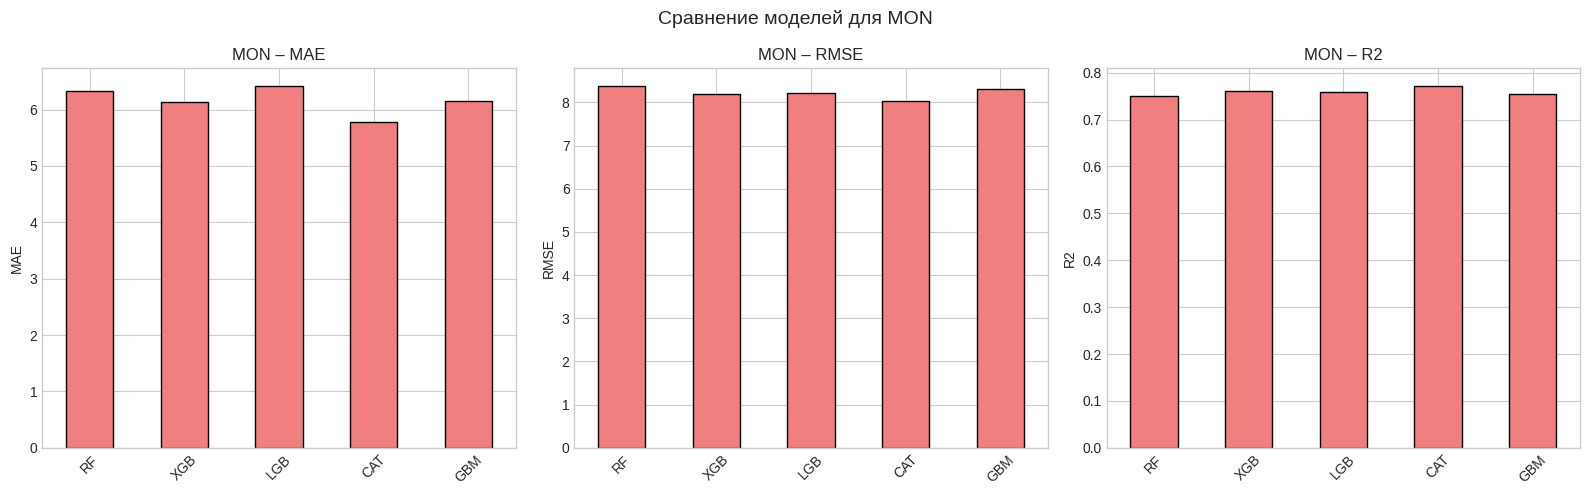

In [25]:
results_mon = {}
for name, model in models_mon.items():
    mae, rmse, r2 = evaluate_model(model, X_test_mon, y_test_mon)
    results_mon[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"MON {name} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.4f}")
df_res_mon = pd.DataFrame(results_mon).T

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    df_res_mon[metric].plot(kind='bar', ax=ax, color='lightcoral', edgecolor='black')
    ax.set_title(f'MON – {metric}')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle('Сравнение моделей для MON', fontsize=14)
plt.tight_layout()
plt.show()

In [26]:
def get_top_n(results_dict, models_dict, n=3):
    top_names = sorted(results_dict.keys(), key=lambda x: results_dict[x]['R2'], reverse=True)[:n]
    return [(name, models_dict[name]) for name in top_names]

top_ron = get_top_n(results_ron, models_ron, n=3)
top_mon = get_top_n(results_mon, models_mon, n=3)
print("Ансамбль RON:", [n for n, _ in top_ron])
print("Ансамбль MON:", [n for n, _ in top_mon])

voting_ron = VotingRegressor(top_ron)
voting_mon = VotingRegressor(top_mon)

voting_ron.fit(X_train_ron, y_train_ron)
voting_mon.fit(X_train_mon, y_train_mon)

mae_r, rmse_r, r2_r = evaluate_model(voting_ron, X_test_ron, y_test_ron)
mae_m, rmse_m, r2_m = evaluate_model(voting_mon, X_test_mon, y_test_mon)
print(f"Ансамбль RON -> MAE: {mae_r:.3f}, RMSE: {rmse_r:.3f}, R2: {r2_r:.4f}")
print(f"Ансамбль MON -> MAE: {mae_m:.3f}, RMSE: {rmse_m:.3f}, R2: {r2_m:.4f}")

Ансамбль RON: ['XGB', 'CAT', 'GBM']
Ансамбль MON: ['CAT', 'XGB', 'LGB']
Ансамбль RON -> MAE: 6.615, RMSE: 8.449, R2: 0.8286
Ансамбль MON -> MAE: 5.917, RMSE: 7.851, R2: 0.7804


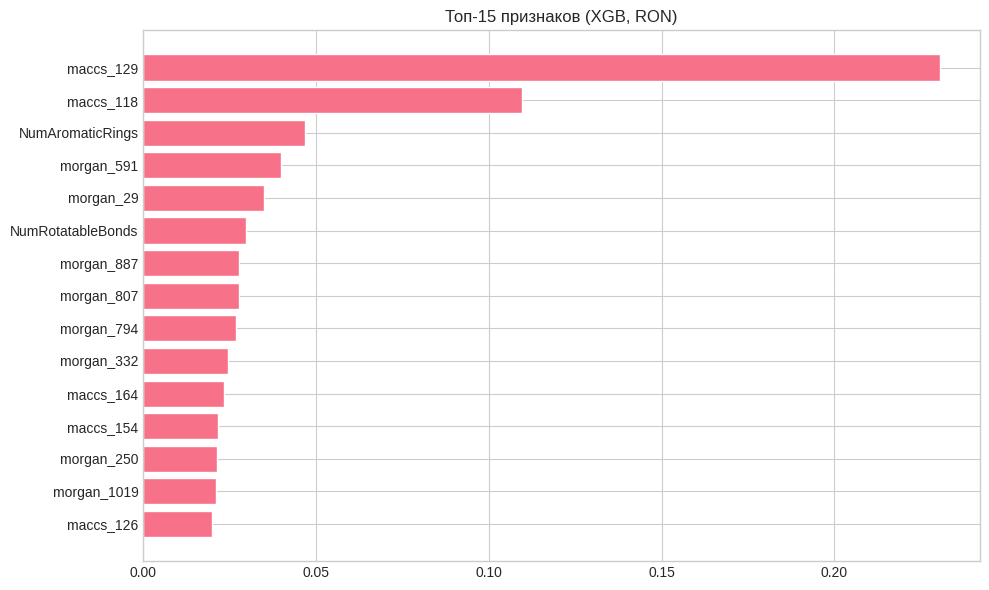

In [27]:
best_ron_name = max(results_ron.keys(), key=lambda x: results_ron[x]['R2'])
best_model = models_ron[best_ron_name]
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_names = X_train_ron.columns
    idx = np.argsort(importances)[::-1][:15]
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(idx)), importances[idx][::-1], align='center')
    plt.yticks(range(len(idx)), feat_names[idx][::-1])
    plt.title(f'Топ-15 признаков ({best_ron_name}, RON)')
    plt.tight_layout()
    plt.show()